### WaveNet-style makemore: character-level name generator

This notebook implements a **WaveNet-inspired character-level model** for generating baby names, closely following Andrej Karpathy's neural networks / makemore video series.

The overall flow mirrors the playlist:
- Load a corpus of baby names and build a character vocabulary
- Convert names into (context, next-character) pairs using a fixed context window
- Define a small WaveNet-style architecture built from simple PyTorch modules
- Train the model with SGD and visualize the training loss
- Evaluate train/validation performance and sample new, name-like strings

All components are written from scratch (no high-level PyTorch modules) to stay in line with the educational style of the original lectures.

### WaveNet Architecture: Dilated Causal Convolution network

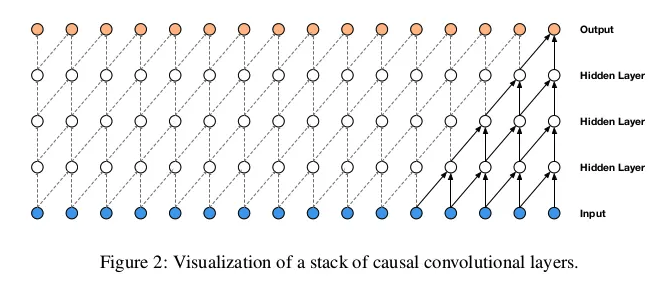

**What WaveNet actually is**

WaveNet is a **dilated causal convolution** network for generating audio. Let me break each word down.

**Causal**: Each output at time t can only depend on inputs at time t and earlier. Never future inputs. This is essential for generation as you generate one sample at a time left to right.

**Convolution**: The same filter is applied across all time steps. Not a fully connected layer.

**Dilated**: This is the key idea. Instead of each neuron looking at adjacent inputs, it looks at inputs **spaced apart by a gap** called the dilation rate.

---

**The dilation pattern**

Layer 1 — dilation = 1. Each neuron looks at inputs 1 step apart.
Layer 2 — dilation = 2. Each neuron looks at inputs 2 steps apart.
Layer 3 — dilation = 4. Each neuron looks at inputs 4 steps apart.
Layer 4 — dilation = 8. Each neuron looks at inputs 8 steps apart.

So dilations double each layer: 1, 2, 4, 8, 16, 32...

This is where your "halving" intuition came from — the pattern does involve powers of 2. But it's the **gap that doubles**, not the neurons that halve.

---

**Why this is clever — receptive field**

The receptive field is how many past time steps an output neuron can "see."

With regular convolutions with kernel size 2:
- After 1 layer → sees 2 steps
- After 2 layers → sees 3 steps
- After n layers → sees n+1 steps

This grows **linearly** — very slow. To see 1000 steps back you'd need 1000 layers.

With dilated convolutions with kernel size 2:
- After 1 layer (dilation 1) → sees 2 steps
- After 2 layers (dilation 2) → sees 4 steps
- After 3 layers (dilation 4) → sees 8 steps
- After n layers → sees $2^n$ steps

This grows **exponentially** — very fast. To see 1024 steps back you only need 10 layers.

This is exactly why WaveNet can model long range dependencies in audio efficiently.

---

**A concrete picture**

```
Output:                y
                      / \
Layer 3 (dil=4):     o   o
                    /|   |\
Layer 2 (dil=2):   o |   | o
                  /| |   | |\
Layer 1 (dil=1): o o o o o o o
              ← receptive field →
```

Each layer the gap doubles. The receptive field grows exponentially. Number of neurons per layer stays the same.

---


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import time
%matplotlib inline

### Loading the names corpus

Here we load the list of baby names used throughout Karpathy's makemore series from `names.txt`:
- Each line is a single name
- We keep the raw Python list of strings for inspection

These raw names will later be tokenized character-by-character and turned into training examples for the WaveNet-style model.

### Character vocabulary and encoding

As in makemore, we build a **character-level vocabulary** over all names:
- Collect the set of unique characters and sort them
- Reserve index `0` for the special `'.'` end-of-word token
- Create mappings `stoi` (string → index) and `itos` (index → string)

This lets us move cleanly between raw text and integer tensors that the WaveNet-style network can operate on.

In [2]:
# Read in all the words
words = open('names.txt', 'r').read().splitlines()
print("Words: ", words[:10])
print("Length: ", len(words))

Words:  ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Length:  32033


In [3]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { ch:i+1 for i,ch in enumerate(chars) }
stoi['.'] = 0
itos = { i:ch for ch, i in stoi.items() }

vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


### Building the character-level dataset

Following makemore, we turn each name into many **(context, next-character)** training examples:
- Fix a `block_size` context window of 8 characters
- Slide this window over each name plus a final end-of-word token `'.'`
- Encode characters to integers using the `stoi` mapping

This produces tensors `X` (contexts) and `Y` (next characters) for train/dev/test splits, which the WaveNet-style model will learn to predict.

In [4]:
# Build the dataset
block_size = 8
X, Y = [], []

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


### WaveNet-style architecture for makemore

Here we define a small **WaveNet-inspired 1D model** using only basic building blocks, mirroring the makemore playlist:
- Custom `Embedding`, `Linear`, `BatchNorm1d`, `Tanh`, and `FlattenConsecutive` modules
- A `Sequential` container to compose layers
- Stacked `FlattenConsecutive` + `Linear` + `BatchNorm1d` + `Tanh` blocks to gradually mix nearby time steps

This results in a causal convolution–like architecture over character embeddings while staying within a simple MLP-style implementation, just like in Karpathy's educational WaveNet videos.

In [22]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, epsilon = 1e-5, momentum = 0.1):
        self.epsilon = epsilon
        self.momentum = momentum
        self.training = True

        # Parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            else:
                raise ValueError(f"Input tensor must have 2 or 3 dimensions, got {x.ndim}")
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.epsilon) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        
        # update the buffers
        # only update the buffers if we are training
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1 - self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1 - self.momentum) * self.running_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
     
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(num_embedding, embedding_dim)

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        """
        Initialize the FlattenConsecutive module.

        Args:
            n (int): Number of consecutive elements to be flattened together along the sequence dimension.
        """
        self.n = n
        
    def __call__(self, x):
        """
        Forward pass to flatten n consecutive positions into the last dimension.

        Args:
            x (torch.Tensor): Input tensor of shape (B, T, C) where B is batch size, 
                              T is sequence length, C is feature dimension.
        
        Returns:
            torch.Tensor: Tensor of shape (B, T//n, C*n). If T//n == 1, returns shape (B, C*n).
        """
        B, T, C = x.shape
        x = x.view(B, T//self.n, self.n * C)
        if x.shape[1] == 1:
            x = x.squeeze(1) # remove dimension of size 1

        self.out = x
        return self.out

    def parameters(self):
        return []
        
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
n_embd = 10 # The dimensionality of the character embedding vectors
n_hidden = 68 # The number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias = False),
    BatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias = False),
    BatchNorm1d(n_hidden),
    Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias = False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    # make the last layer less confident
    model.layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in model.layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = model.parameters()
print("Total parameters: ", sum(p.numel() for p in parameters))
    
for p in parameters:
    p.requires_grad = True

Total parameters:  22397


In [23]:
# ix = torch.randint(0, Xtr.shape[0], (4,), generator=g) # let's try 4 examples
# Xb, Yb = Xtr[ix], Ytr[ix]

# logits = model(Xb)

# for layer in model.layers:
#     print(layer.__class__.__name__, ':', tuple(layer.out.shape))

### Training the WaveNet-style character model

This cell runs the **SGD training loop** almost exactly as in Karpathy's makemore series:
- Sample random mini-batches from the training set
- Forward pass through the WaveNet-style network to get logits over the next character
- Compute cross-entropy loss vs. the ground-truth next character
- Backpropagate gradients and update parameters with a simple learning rate schedule

We also track log
t10 loss values in `lossi` so we can later visualize how training progresses over time.

In [24]:
#  Optimization
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150_000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:05d}/{max_steps:05d} loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())

00000/200000 loss: 3.2864
10000/200000 loss: 2.2785
20000/200000 loss: 1.9783
30000/200000 loss: 2.0566
40000/200000 loss: 2.0830
50000/200000 loss: 1.6267
60000/200000 loss: 2.2378
70000/200000 loss: 1.7693
80000/200000 loss: 2.3370
90000/200000 loss: 2.1283
100000/200000 loss: 1.6678
110000/200000 loss: 1.9317
120000/200000 loss: 1.9928
130000/200000 loss: 2.0258
140000/200000 loss: 2.2971
150000/200000 loss: 2.1608
160000/200000 loss: 1.9573
170000/200000 loss: 1.7885
180000/200000 loss: 2.1565
190000/200000 loss: 2.0935


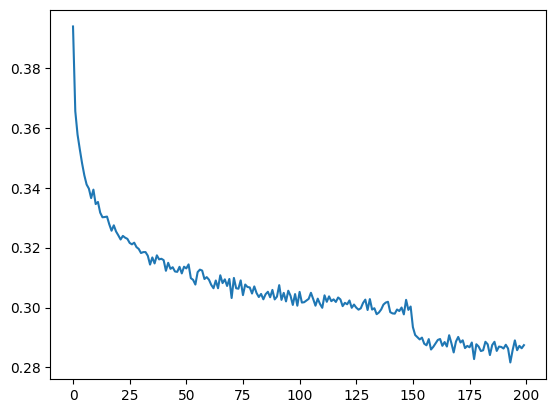

In [25]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [26]:
# Put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

### Evaluating train/val loss

Here we follow Karpathy's makemore workflow and compute **full-dataset cross-entropy loss** on the train and validation splits:
- Put the model in evaluation mode (BatchNorm uses running stats)
- Run the model once on each split
- Report the average negative log-likelihood per character

This gives a quick sanity check that the model has actually learned and that validation loss is reasonably close to training loss (i.e., not severely overfitting).

In [27]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9179362058639526
val 2.0180001258850098


### Sampling new names

Now that the WaveNet-style character model is trained, we autoregressively **sample one character at a time**. Starting from a context of all `'.'` tokens, we repeatedly:
- Feed the current context through the model to get logits over the next character
- Convert logits to probabilities with `softmax`
- Sample the next character index from this distribution
- Shift the context window and continue until we hit the end-of-word token `'.'`

This reproduces the sampling procedure from Karpathy's makemore series, generating baby-name-like strings from the learned distribution.

In [28]:
# Sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # Forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim = 1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # If we sample special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

mai.
anjalyah.
lislav.
rianey.
hames.
zahmi.
adawan.
carcoda.
luca.
bryxlee.
shaimon.
viran.
munolai.
zekariel.
tya.
shuv.
haavir.
jaiyah.
shom.
umniquo.
